<a href="https://colab.research.google.com/github/Angel-bit-13/AI-chatbot/blob/main/uber_cancellation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install opendatasets

| Day       | Topics                                 | Tasks                                                                                                                                                                                                                                                                                                                                    | Outcome                                       |
| --------- | -------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------- |
| **Day 1** | Dataset Understanding + Preprocessing  | - Download dataset  <br> - Load CSV using Pandas  <br> - Understand columns using `info()` and `describe()`  <br> - Check missing values  <br> - Convert Date & Time columns  <br> - Create datetime features (`hour`, `day`, `month`, `weekday`, `is_weekend`)  <br> - Create cancellation flags  <br> - Handle missing values          | Cleaned and prepared dataset                  |
| **Day 2** | Exploratory Data Analysis (EDA)        | - Understand target variable  <br> - Analyze cancellation distribution  <br> - Plot cancellation rate by vehicle type  <br> - Plot cancellation by hour and weekday  <br> - Driver rating analysis  <br> - Top pickup location analysis  <br> - Daily cancellation trend  <br> - Heatmap analysis                                        | Insights about customer cancellations         |
| **Day 3** | Feature Engineering + Data Preparation | - One-hot encoding for vehicle type  <br> - Encode pickup/drop locations  <br> - Create customer booking frequency feature  <br> - Drop unnecessary columns  <br> - Select features and target  <br> - Handle class imbalance using class weights  <br> - Correlation analysis  <br> - Train-test split  <br> - Missing value imputation | Final ML-ready dataset                        |
| **Day 4** | Model Building + Evaluation            | - Train Logistic Regression  <br> - Evaluate ROC-AUC, Precision, Recall, F1-score  <br> - Train Random Forest  <br> - Train XGBoost  <br> - Compare models  <br> - Generate predictions  <br> - Create prediction summary table  <br> - Final conclusion and result analysis                                                             | Final predictive model and project completion |


In [ ]:
import pandas as pd
import opendatasets as od

In [ ]:
od.download('https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: 
Your Kaggle username: angelinraison
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard


100%|██████████| 16.5M/16.5M [00:00<00:00, 127MB/s]


In [ ]:
uber=pd.read_csv("/content/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

In [ ]:
uber.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [ ]:
uber.duplicated().sum()

np.int64(0)

In [ ]:
uber.fillna(0)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,0,0.0,0,0.0,0,0.0,0.00,0.0,0.0,0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,0,0.0,0,1.0,Vehicle Breakdown,237.0,5.73,0.0,0.0,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,0,0.0,0,0.0,0,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,0,0.0,0,0.0,0,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,0,0.0,0,0.0,0,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,0,0.0,0,0.0,0,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,0,0.0,0,0.0,0,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,0,0.0,0,0.0,0,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,0,0.0,0,0.0,0,333.0,45.54,4.1,3.7,UPI


In [ ]:
uber.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [ ]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [ ]:
uber

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [ ]:
uber.fillna(0,inplace=True)

In [ ]:
uber

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,0,0.0,0,0.0,0,0.0,0.00,0.0,0.0,0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,0,0.0,0,1.0,Vehicle Breakdown,237.0,5.73,0.0,0.0,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,0,0.0,0,0.0,0,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,0,0.0,0,0.0,0,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,0,0.0,0,0.0,0,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,0,0.0,0,0.0,0,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,0,0.0,0,0.0,0,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,0,0.0,0,0.0,0,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,0,0.0,0,0.0,0,333.0,45.54,4.1,3.7,UPI


In [ ]:
uber.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,7.864407,19.821753,0.070000,0.180000,0.060000,345.641220,16.753168,2.623215,2.730842
std,4.230640,15.452834,0.255148,0.384189,0.237488,403.423487,16.291118,2.082283,2.165548
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.800000,22.000000,0.000000,0.000000,0.000000,244.000000,13.060000,3.900000,4.100000
75%,11.000000,32.900000,0.000000,0.000000,0.000000,521.000000,30.650000,4.300000,4.600000
max,20.000000,45.000000,1.000000,1.000000,1.000000,4277.000000,50.000000,5.000000,5.000000


In [ ]:
uber['DateTime']= pd.to_datetime(uber['Date'].astype(str) + ' ' + uber['Time'].astype(str),errors='coerce')
print(uber[['Date','Time','DateTime']].head())

         Date      Time            DateTime
0  2024-03-23  12:29:38 2024-03-23 12:29:38
1  2024-11-29  18:01:39 2024-11-29 18:01:39
2  2024-08-23  08:56:10 2024-08-23 08:56:10
3  2024-10-21  17:17:25 2024-10-21 17:17:25
4  2024-09-16  22:08:00 2024-09-16 22:08:00


In [ ]:
uber['Hour']=uber['DateTime'].dt.hour
uber['Day']=uber['DateTime'].dt.day
uber['Month']=uber['DateTime'].dt.month
uber['Weekday']=uber['DateTime'].dt.day_name()
uber['Weekend']=uber['DateTime'].dt.dayofweek.isin([5,6])

In [ ]:
uber

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Ride Distance,Driver Ratings,Customer Rating,Payment Method,DateTime,Hour,Day,Month,Weekday,Weekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,0.00,0.0,0.0,0,2024-03-23 12:29:38,12,23,3,Saturday,True
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,5.73,0.0,0.0,UPI,2024-11-29 18:01:39,18,29,11,Friday,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,23,8,Friday,False
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,21,10,Monday,False
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,16,9,Monday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,40.08,3.7,4.1,Uber Wallet,2024-11-11 19:34:01,19,11,11,Monday,False
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,21.31,4.8,5.0,UPI,2024-11-24 15:55:09,15,24,11,Sunday,True
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,15.93,3.9,4.4,Cash,2024-09-18 10:55:15,10,18,9,Wednesday,False
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,45.54,4.1,3.7,UPI,2024-10-05 07:53:34,7,5,10,Saturday,True


In [ ]:
# Create binary flags from cancellation/incomplete columns
uber['is_cancelled_customer'] = uber['Cancelled Rides by Customer'].astype(bool) # Identifies customer-cancelled rides.
uber['is_cancelled_driver'] = uber['Cancelled Rides by Driver'].astype(bool) # Identifies driver-cancelled rides.
uber['is_incomplete'] = uber['Incomplete Rides'].astype(bool) # Identifies incomplete rides.

# Create a flag for missing ratings and booking values (these will all be False after fillna(0) earlier)
uber['missing_driver_rating'] = uber['Driver Ratings'].isnull()  # Creates missing-driver-rating indicator.
uber['missing_customer_rating'] = uber['Customer Rating'].isnull() # Creates missing-customer-rating indicator.
uber['missing_booking_value'] = uber['Booking Value'].isnull() # Detects missing booking values.
uber['missing_payment_method'] = uber['Payment Method'].isnull() # Detects missing payment methods.

# Optional: Fill CTAT and VTAT with median if needed (these were already filled with 0 earlier)
# uber['Avg VTAT'] = uber['Avg VTAT'].fillna(uber['Avg VTAT'].median())
# uber['Avg CTAT'] = uber['Avg CTAT'].fillna(uber['Avg CTAT'].median())

# Check new flags
uber[['is_cancelled_customer', 'is_cancelled_driver', 'is_incomplete',
    'missing_driver_rating', 'missing_customer_rating',
    'missing_booking_value', 'missing_payment_method']].sum()

,0
is_cancelled_customer,10500
is_cancelled_driver,27000
is_incomplete,9000
missing_driver_rating,0
missing_customer_rating,0
missing_booking_value,0
missing_payment_method,0


In [ ]:
uber

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Month,Weekday,Weekend,is_cancelled_customer,is_cancelled_driver,is_incomplete,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,0.0,0.0,...,3,Saturday,True,False,False,False,False,False,False,False
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,11,Friday,False,False,False,True,False,False,False,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,8,Friday,False,False,False,False,False,False,False,False
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,10,Monday,False,False,False,False,False,False,False,False
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,9,Monday,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,11,Monday,False,False,False,False,False,False,False,False
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,11,Sunday,True,False,False,False,False,False,False,False
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,9,Wednesday,False,False,False,False,False,False,False,False
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,10,Saturday,True,False,False,False,False,False,False,False


In [ ]:
# Target variable
uber['target_customer_cancelled'] = uber['is_cancelled_customer'].astype(int)  # Creates binary target variable for prediction.

# Quick target distribution check
uber['target_customer_cancelled'].value_counts(normalize=True) # Checks class imbalance.Shows percentage distribution of classes

,proportion
target_customer_cancelled,
0,0.93
1,0.07


In [ ]:
uber['is_cancelled_customer'].value_counts()

,count
is_cancelled_customer,
False,139500
True,10500


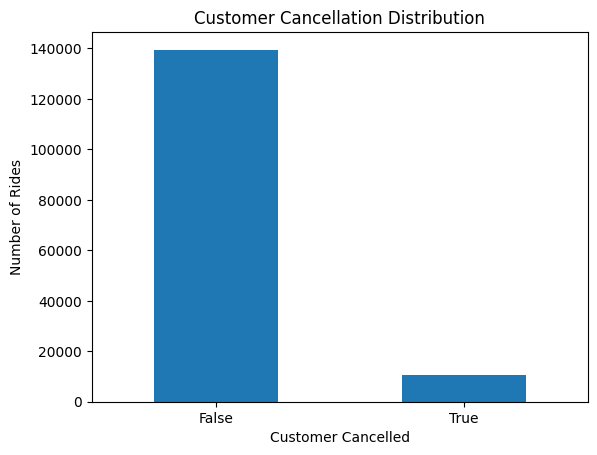

In [ ]:
import matplotlib.pyplot as plt

# Count customer cancellations
cancel_counts = uber['is_cancelled_customer'].value_counts()

# Plot bar graph
cancel_counts.plot(kind='bar')

# Labels and title
plt.title('Customer Cancellation Distribution')
plt.xlabel('Customer Cancelled')
plt.ylabel('Number of Rides')

# Rename x-axis labels
plt.xticks([0,1], ['False', 'True'], rotation=0)

plt.show()

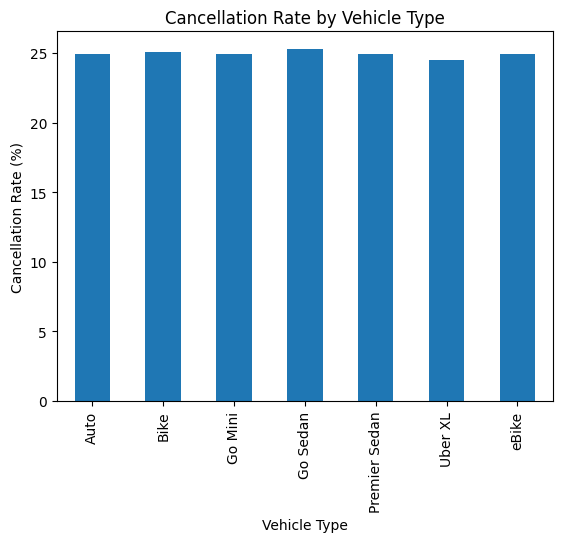

In [ ]:
import pandas as pd

# Create cancellation flag
uber['is_cancelled'] = uber['Booking Status'].str.contains('Cancelled', case=False)

# Cancellation rate by vehicle type
cancel_rate = uber.groupby('Vehicle Type')['is_cancelled'].mean() * 100

# Plot
cancel_rate.plot(kind='bar')

plt.title('Cancellation Rate by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Cancellation Rate (%)')
plt.show()

/tmp/ipykernel_1715/1713697174.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  uber['hour'] = pd.to_datetime(uber['Time']).dt.hour


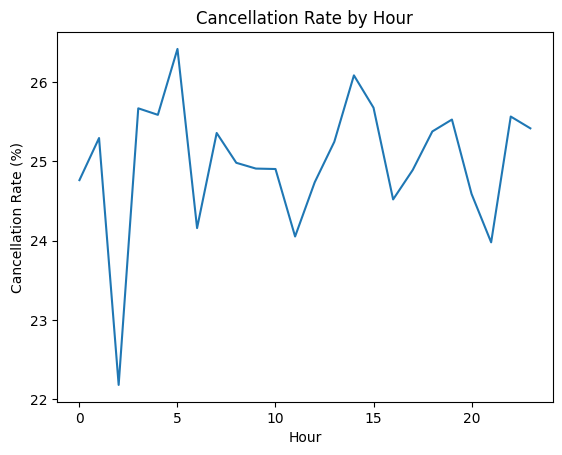

In [ ]:
# Extract hour
uber['hour'] = pd.to_datetime(uber['Time']).dt.hour

# Hourly cancellation rate
hourly_cancel = uber.groupby('hour')['is_cancelled'].mean() * 100

# Plot
hourly_cancel.plot()

plt.title('Cancellation Rate by Hour')
plt.xlabel('Hour')
plt.ylabel('Cancellation Rate (%)')
plt.show()

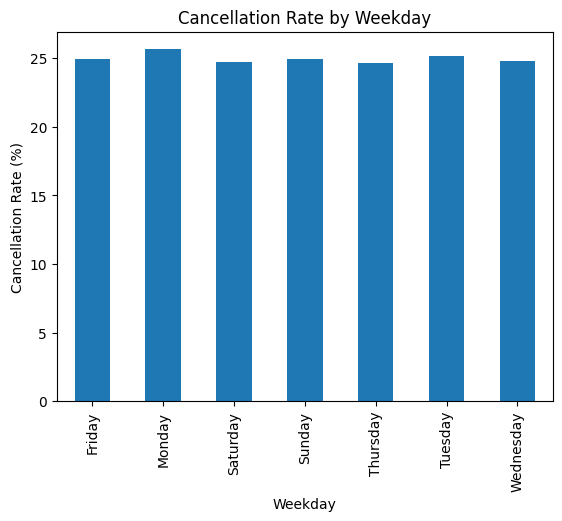

In [ ]:
# Extract weekday
uber['weekday'] = pd.to_datetime(uber['Date']).dt.day_name()

# Weekday cancellation rate
weekday_cancel = uber.groupby('weekday')['is_cancelled'].mean() * 100

# Plot
weekday_cancel.plot(kind='bar')

plt.title('Cancellation Rate by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Cancellation Rate (%)')
plt.show()

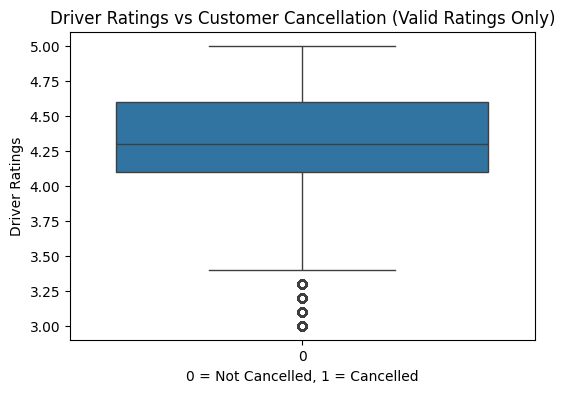

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered = uber[uber['Driver Ratings'] > 0]

plt.figure(figsize=(6,4))
sns.boxplot(x='target_customer_cancelled', y='Driver Ratings', data=filtered)
plt.title('Driver Ratings vs Customer Cancellation (Valid Ratings Only)')
plt.xlabel('0 = Not Cancelled, 1 = Cancelled')
plt.ylabel('Driver Ratings')
plt.show()

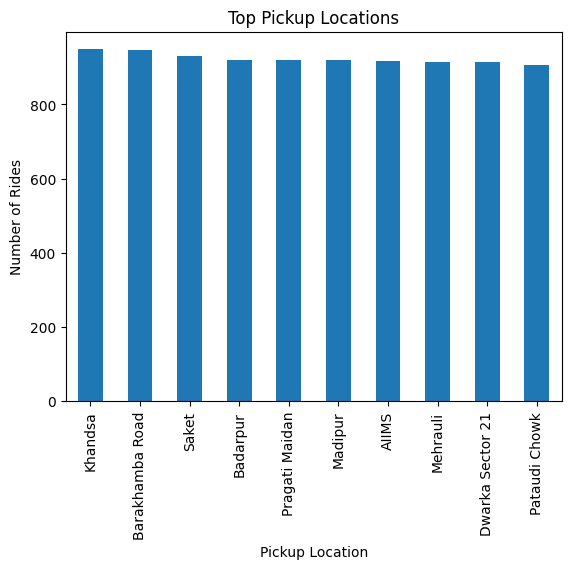

In [ ]:
# Top pickup locations
top_pickups = uber['Pickup Location'].value_counts().head(10)

# Plot
top_pickups.plot(kind='bar')

plt.title('Top Pickup Locations')
plt.xlabel('Pickup Location')
plt.ylabel('Number of Rides')
plt.show()

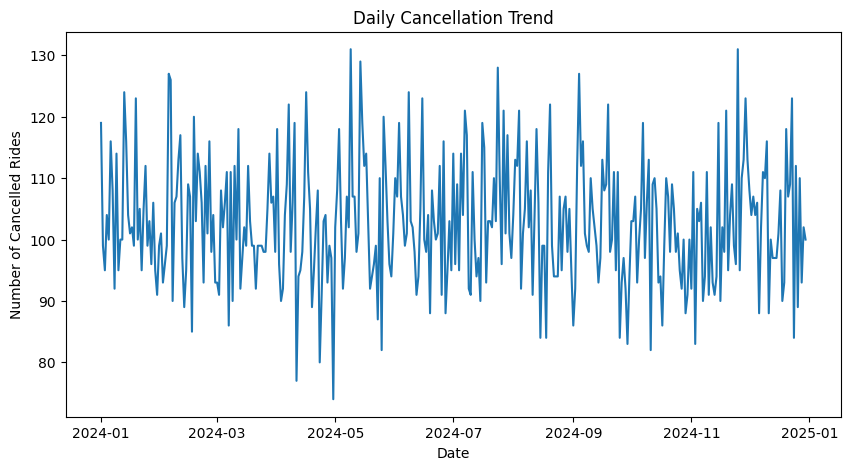

In [ ]:
# Convert to datetime
uber['Date'] = pd.to_datetime(uber['Date'])

# Daily cancellations
daily_cancel = uber.groupby(uber['Date'].dt.date)['is_cancelled'].sum()

# Plot
daily_cancel.plot(figsize=(10,5))

plt.title('Daily Cancellation Trend')
plt.xlabel('Date')
plt.ylabel('Number of Cancelled Rides')
plt.show()

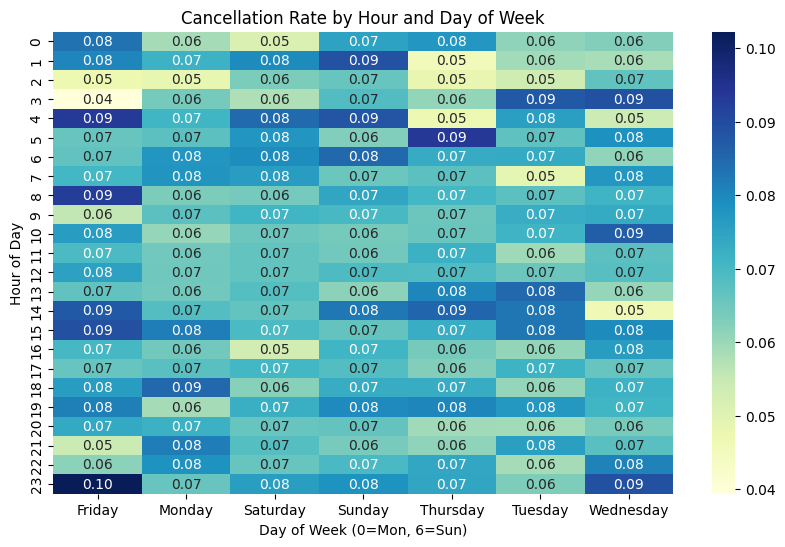

In [ ]:
heatmap_data = uber.pivot_table(
    index='hour',
    columns='weekday',
    values='target_customer_cancelled',
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Cancellation Rate by Hour and Day of Week")
plt.ylabel("Hour of Day")
plt.xlabel("Day of Week (0=Mon, 6=Sun)")
plt.show()

In [ ]:
# One-hot encoding for Vehicle Type
vehicle_encoded = pd.get_dummies(uber['Vehicle Type'], prefix='Vehicle')

# Add encoded columns to dataset
uber = pd.concat([uber, vehicle_encoded], axis=1)

# View encoded columns
vehicle_encoded.head()

,Vehicle_Auto,Vehicle_Bike,Vehicle_Go Mini,Vehicle_Go Sedan,Vehicle_Premier Sedan,Vehicle_Uber XL,Vehicle_eBike
0,False,False,False,False,False,False,True
1,False,False,False,True,False,False,False
2,True,False,False,False,False,False,False
3,False,False,False,False,True,False,False
4,False,True,False,False,False,False,False


In [ ]:
import pandas as pd

# One-hot encode Pickup Location
pickup_encoded = pd.get_dummies(
    uber['Pickup Location'],
    prefix='Pickup',
    dtype=int
)

# One-hot encode Drop Location
drop_encoded = pd.get_dummies(
    uber['Drop Location'],
    prefix='Drop',
    dtype=int
)

# Add encoded columns to original dataset
uber = pd.concat([uber, pickup_encoded, drop_encoded], axis=1)

# Display first few encoded columns
for i in range(5):
    print(pickup_encoded.iloc[i][pickup_encoded.iloc[i] == 1])
    print(drop_encoded.iloc[i][drop_encoded.iloc[i] == 1])
    print()

Pickup_Palam Vihar    1
Name: 0, dtype: int64
Drop_Jhilmil    1
Name: 0, dtype: int64

Pickup_Shastri Nagar    1
Name: 1, dtype: int64
Drop_Gurgaon Sector 56    1
Name: 1, dtype: int64

Pickup_Khandsa    1
Name: 2, dtype: int64
Drop_Malviya Nagar    1
Name: 2, dtype: int64

Pickup_Central Secretariat    1
Name: 3, dtype: int64
Drop_Inderlok    1
Name: 3, dtype: int64

Pickup_Ghitorni Village    1
Name: 4, dtype: int64
Drop_Khan Market    1
Name: 4, dtype: int64



In [ ]:
# Create customer booking frequency feature
uber['customer_booking_frequency'] = (
    uber.groupby('Customer ID')['Booking ID']
    .transform('count')
)

# View result
print(
    uber[['Customer ID', 'Booking ID',
    'customer_booking_frequency']].head()
)

    Customer ID    Booking ID  customer_booking_frequency
0  "CID1982111"  "CNR5884300"                           1
1  "CID4604802"  "CNR1326809"                           1
2  "CID9202816"  "CNR8494506"                           1
3  "CID2610914"  "CNR8906825"                           1
4  "CID9933542"  "CNR1950162"                           1


In [ ]:
uber_backup=uber.copy()

In [ ]:
# Drop unnecessary columns
uber = uber.drop(columns=[
    'Booking ID',
    'Customer ID',
    'Pickup Location',
    'Drop Location',
    'Reason for cancelling by Customer',
    'Driver Cancellation Reason',
    'Incomplete Rides Reason'
])

# Check remaining columns
print(uber.columns)

Index(['Date', 'Time', 'Booking Status', 'Vehicle Type', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer', 'Cancelled Rides by Driver',
       'Incomplete Rides', 'Booking Value',
       ...
       'Drop_Uttam Nagar', 'Drop_Vaishali', 'Drop_Vasant Kunj',
       'Drop_Vatika Chowk', 'Drop_Vidhan Sabha', 'Drop_Vinobapuri',
       'Drop_Vishwavidyalaya', 'Drop_Welcome', 'Drop_Yamuna Bank',
       'customer_booking_frequency'],
      dtype='object', length=391)


In [ ]:
# Select features (X)
X = uber.drop(columns=['target_customer_cancelled'])

# Select target variable (y)
y = uber['target_customer_cancelled']

# Check shapes
print(X.shape)
print(y.shape)
X.head()

(150000, 390)
(150000,)


,Date,Time,Booking Status,Vehicle Type,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,...,Drop_Uttam Nagar,Drop_Vaishali,Drop_Vasant Kunj,Drop_Vatika Chowk,Drop_Vidhan Sabha,Drop_Vinobapuri,Drop_Vishwavidyalaya,Drop_Welcome,Drop_Yamuna Bank,customer_booking_frequency
0,2024-03-23,12:29:38,No Driver Found,eBike,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
1,2024-11-29,18:01:39,Incomplete,Go Sedan,4.9,14.0,0.0,0.0,1.0,237.0,...,0,0,0,0,0,0,0,0,0,1
2,2024-08-23,08:56:10,Completed,Auto,13.4,25.8,0.0,0.0,0.0,627.0,...,0,0,0,0,0,0,0,0,0,1
3,2024-10-21,17:17:25,Completed,Premier Sedan,13.1,28.5,0.0,0.0,0.0,416.0,...,0,0,0,0,0,0,0,0,0,1
4,2024-09-16,22:08:00,Completed,Bike,5.3,19.6,0.0,0.0,0.0,737.0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Convert to dictionary
class_weights = dict(zip(np.unique(y), class_weights))

# Display class weights
print(class_weights)

{np.int64(0): np.float64(0.5376344086021505), np.int64(1): np.float64(7.142857142857143)}


In [ ]:
# Remove Pickup and Drop columns
drop_cols = [col for col in uber.columns if 'Pickup_' in col or 'Drop_' in col]

uber = uber.drop(columns=drop_cols)

# Keep numeric columns
uber_numeric = uber.select_dtypes(include=['number'])


print(uber_numeric.shape)

(150000, 15)


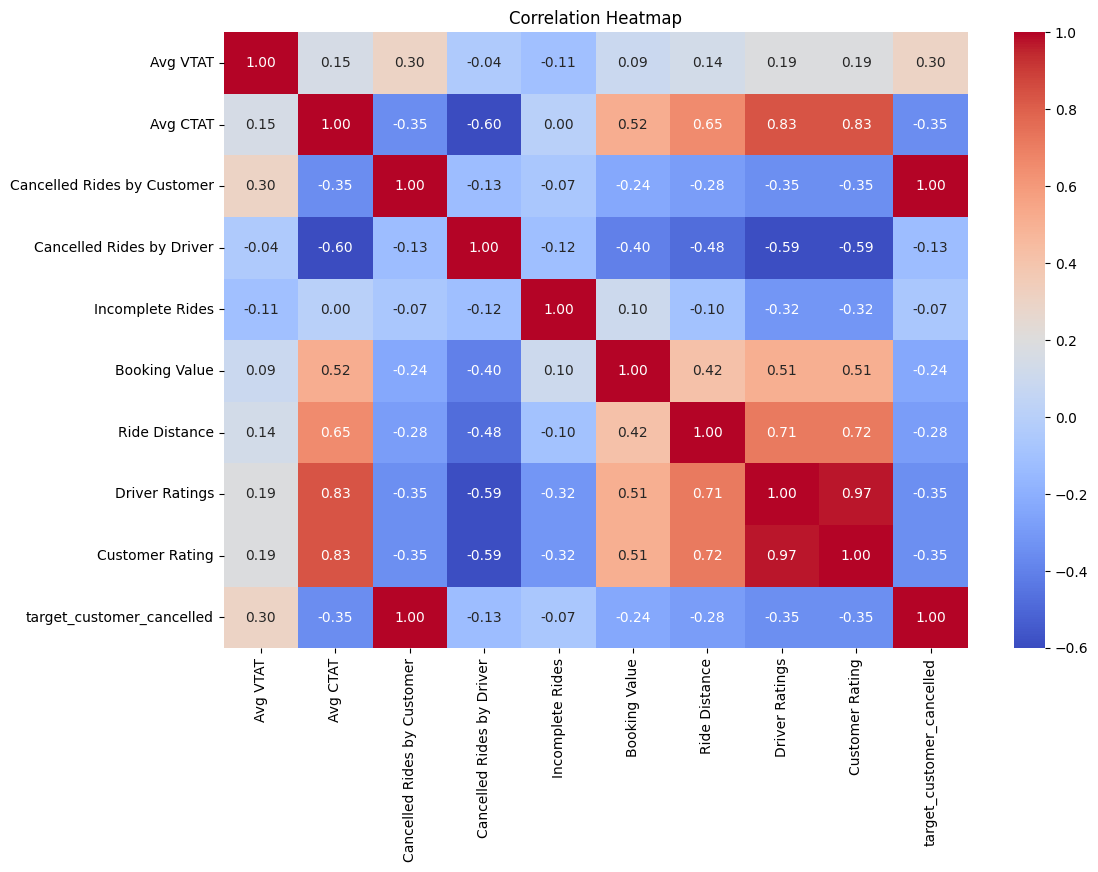

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation matrix
corr_matrix = uber_numeric.corr()

# Correlation with target column
target_corr = corr_matrix['target_customer_cancelled']

# Keep only useful correlations
useful_corr = target_corr[abs(target_corr) > 0.05]

# Get useful columns
useful_columns = useful_corr.index

# Create filtered correlation matrix
filtered_corr = uber_numeric[useful_columns].corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    filtered_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120000, 390)
(30000, 390)
(120000,)
(30000,)


In [ ]:
# Fill missing numerical values with median
uber['Avg VTAT'] = uber['Avg VTAT'].fillna(
    uber['Avg VTAT'].median()
)

uber['Avg CTAT'] = uber['Avg CTAT'].fillna(
    uber['Avg CTAT'].median()
)

uber['Booking Value'] = uber['Booking Value'].fillna(
    uber['Booking Value'].median()
)

# Fill missing ratings with 0
uber['Driver Ratings'] = uber['Driver Ratings'].fillna(0)

uber['Customer Rating'] = uber['Customer Rating'].fillna(0)

# Fill missing categorical values with 'Unknown'
uber['Payment Method'] = uber['Payment Method'].fillna('Unknown')

# Check remaining missing values
print(uber.isnull().sum())

Date                           0
Time                           0
Booking Status                 0
Vehicle Type                   0
Avg VTAT                       0
Avg CTAT                       0
Cancelled Rides by Customer    0
Cancelled Rides by Driver      0
Incomplete Rides               0
Booking Value                  0
Ride Distance                  0
Driver Ratings                 0
Customer Rating                0
Payment Method                 0
DateTime                       0
Hour                           0
Day                            0
Month                          0
Weekday                        0
Weekend                        0
is_cancelled_customer          0
is_cancelled_driver            0
is_incomplete                  0
missing_driver_rating          0
missing_customer_rating        0
missing_booking_value          0
missing_payment_method         0
target_customer_cancelled      0
is_cancelled                   0
hour                           0
weekday   

In [ ]:
leakage_cols = [
    'Cancelled Rides by Customer',
    'Cancelled Rides by Driver',
    'target_customer_cancelled'
]

X = uber_numeric.drop(columns=leakage_cols, errors='ignore')

y = uber_numeric['target_customer_cancelled']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

y_prob = lr.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      0.86      0.92     27900
           1       0.34      0.95      0.50      2100

    accuracy                           0.87     30000
   macro avg       0.67      0.91      0.71     30000
weighted avg       0.95      0.87      0.89     30000

ROC-AUC: 0.9632813961426865


In [ ]:
# ================================
# Train Random Forest
# ================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("RANDOM FOREST RESULTS")
print()

print(classification_report(y_test, rf_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, rf_prob))

RANDOM FOREST RESULTS

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     27900
           1       0.83      0.55      0.66      2100

    accuracy                           0.96     30000
   macro avg       0.90      0.77      0.82     30000
weighted avg       0.96      0.96      0.96     30000

ROC-AUC Score: 0.9616869943676394


In [ ]:
# ================================
#  Train XGBoost
# ================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Probabilities
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBOOST RESULTS")
print()

print(classification_report(y_test, xgb_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, xgb_prob))

XGBOOST RESULTS

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     27900
           1       1.00      0.52      0.69      2100

    accuracy                           0.97     30000
   macro avg       0.98      0.76      0.83     30000
weighted avg       0.97      0.97      0.96     30000

ROC-AUC Score: 0.9652280423280424


In [ ]:
# ================================
# STEP 6 — Compare Models
# ================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(comparison)

                 Model   ROC-AUC
0  Logistic Regression  0.963281
1        Random Forest  0.961687
2              XGBoost  0.965228


In [ ]:
# ================================
# GENERATE PREDICTIONS
# ================================

# Using best model (XGBoost)

final_predictions = xgb_model.predict(X_test)

# Prediction probabilities
final_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# Display first 10 predictions
print("Predicted Classes:")
print(final_predictions[:10])

print()

print("Prediction Probabilities:")
print(final_probabilities[:10])

Predicted Classes:
[0 0 0 0 0 0 0 0 0 0]

Prediction Probabilities:
[1.88366443e-01 1.15097564e-05 1.15097564e-05 2.10021809e-01
 1.14410195e-05 2.27125376e-01 1.13949818e-05 2.11798236e-01
 7.11120447e-05 1.90803200e-01]


In [ ]:
# Find best model based on ROC-AUC score

best_model = comparison.loc[
    comparison['ROC-AUC'].idxmax()
]

print("Best Performing Model:\n")
print(best_model)

Best Performing Model:

Model       XGBoost
ROC-AUC    0.965228
Name: 2, dtype: object


In [ ]:
import pandas as pd
import numpy as np

# ======================================
# NEW RIDE INPUT
# ======================================

new_ride_input = {

    'Avg VTAT': 10,
    'Avg CTAT': 20,
    'Incomplete Rides': 200,
    'Booking Value': 500,
    'Ride Distance': 12,
    'Driver Ratings': 4,
    'Customer Rating': 5,
    'Weekend': 1,
    'missing_driver_rating': 0,
    'missing_customer_rating': 0,
    'missing_booking_value': 0,
    'missing_payment_method': 0,
    'customer_booking_frequency': 3
}

# ======================================
# CREATE DATAFRAME
# ======================================

new_ride_df = pd.DataFrame([new_ride_input])

# ======================================
# MATCH TRAINING COLUMNS
# ======================================

model_features = X.columns

# Add missing columns
for col in model_features:
    if col not in new_ride_df.columns:
        new_ride_df[col] = 0

# Remove extra columns
new_ride_df = new_ride_df[model_features]

# ======================================
# PREDICTION
# ======================================

prediction = xgb_model.predict(new_ride_df)

prediction_prob = xgb_model.predict_proba(new_ride_df)[:, 1]

# ======================================
# OUTPUT
# ======================================

print("Cancellation Probability:", prediction_prob[0])

if prediction[0] == 1:
    print("Predicted Result: Cancelled ❌")
else:
    print("Predicted Result: Not Cancelled ✅")

Cancellation Probability: 1.1238034e-05
Predicted Result: Not Cancelled ✅
